<font color ='Navy'><center> __BruFace__ </center></font>
<br> MA1 Mechanical Engineering <br>  __Mechanical vibrations__ <br> <br>
***
***
<font color='Navy'><h1><center>Session 3 : Multiple DOF system</center></h1></font>
***
 <div class="alert alert-block alert-info">
<center><b>Welcome to the third session </b></center></div>
    
During the practical session, we will use the same libraries as the ones used in the previous sessions.

<div class="alert alert-block alert-info">
<center><b>Don't forget :It is important that you run each cell of the notebook. To do so select a cell (it will be highlighted) and press shift+enter on your keyboard or the play button in the menu above.</b></center></div>

In [105]:
import sys
import os

# Only if the session is opened in google colab link
if "google.colab" in sys.modules:
    repo = "/content/MV2627_Exercises"
    if not os.path.exists(repo):
        !git clone -q https://github.com/OWI-Lab/MV2627_Exercises.git {repo}
    %cd /content/MV2627_Exercises/Session3_MDOF
    !pip install -q uv
    !uv pip install --system ipympl ipywidgets jupyterlab-widgets
    from google.colab import output
    output.enable_custom_widget_manager()

/content/MV2627_Exercises/Session3_MDOF
Using Python 3.13.16 environment at: /usr
Checked 3 packages in 94ms


In [106]:
# let's import both numpy and matplotlib.pyplot
# the "as" in the code bellow is to tell python that if we reference to the package using np and plt
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as linalg
# For local use : %matplotlib notebook; for use on jupyterLab: %matplotlib widget
%matplotlib widget

ValueError: Key backend: 'module://ipympl.backend_nbagg' is not a valid value for backend; supported values are ['gtk3agg', 'gtk3cairo', 'gtk4agg', 'gtk4cairo', 'macosx', 'nbagg', 'notebook', 'qtagg', 'qtcairo', 'qt5agg', 'qt5cairo', 'tkagg', 'tkcairo', 'webagg', 'wx', 'wxagg', 'wxcairo', 'agg', 'cairo', 'pdf', 'pgf', 'ps', 'svg', 'template', 'inline']

# Exercises

## Exercise 1: Fundamental equations of an MDOF system

Consider the following three-degree-of-freedom (3 DOFs) system :
<img src="https://github.com/OWI-Lab/MV2627_Exercises/blob/main/Session3_MDOF/Images/MDOF.png?raw=1" width=400 height=400 />


<div style="border-left: 1px solid black; padding: 1em; margin: 1em 0;">

<b> Assignment 1.1:</b> Write the equation of motion in the time domain for the system (in LaTeX)  in the cell below:

(If you are not familiar with LaTeX you can use: https://www.hostmath.com/ and copy the LaTeX below, or write it on paper for yourself)

YOUR ANSWER HERE

<div style="border-left: 1px solid black; padding: 1em; margin: 1em 0;">

<b> Assignment 1.2:</b> Create a function `build_3DOF_matrices` that takes as arguments the stiffnesses $k$ and $k_1$, the damping values $c$ and $c_1$ and the mass $m$ and computes the system matrices ($M$, $C$, $K$). In the cell below we have given you a start, we show how you can use `np.array` to build the $M$-matrix.

In [32]:
def build_3DOF_matrices(m:float,c:float,c1:float,k:float,k1:float):
    """
    Implement a function that computes the build the system matrix for a 3DOF matrix

    Arguments:
    m,k,k1,c,c1 -- parameters of the MDOF system

    Returns:
    M_mat : The M matrix from the system equation
    K_mat : The K matrix from the system equation
    C_mat : The C matrix from the system equation

    Tips use np.array([[],[],[]]) to define your 2D matrix
    check documentation FMI 'Numpy.array()'
    """
    # here is an example of how to set a matrix

    # YOUR CODE HERE
    M_mat = np.array([[m,0,0],
                      [0,m,0],
                      [0,0,m]])
    C_mat = np.array([[c1+c, -c, 0],
                      [-c,2*c,-c],
                      [0,-c,c]])
    K_mat = np.array([[k1+k, -k, 0],
                      [-k,2*k,-k],
                      [0,-k,k]])
    return M_mat, C_mat, K_mat

In the cell below we will check if you implemented the function correctly. To do so we will use several properties of the system matrices.  Do you understand all the checks that are being done?

In [33]:
M, C, K = build_3DOF_matrices(m=1, k=10, k1=10, c=0.1, c1=0.1)

assert np.array_equal(M, np.eye(3)), 'M-matrix is not diagonal' # Mass matrix is a diagonal matrix

for matrix in [M,C,K]: # Iterate over the three matrices
    assert np.size(matrix,0) == np.size(matrix, 1), f'{matrix} is not square' # All three matrices should be square
    assert np.size(matrix,0) == 3, f'{matrix} is not 3x3' # For a 3DOF system we expect the system matrices to be 3X3 matrix
    assert np.allclose(matrix, matrix.T), f'{matrix} is not symmetric' # The matrices should be symmetric
    # The next one is a bit special, we assert whether or not the matrix is positive definite
    assert np.all(np.linalg.eigvals(matrix) > 0), f'{matrix} is not positive definite'
# Some final checks
assert K[2,2] == 10
assert np.sum(K) == 10,  'The K matrix has an error in it'
assert np.sum(C) == 0.1, 'The C matrix has an error in it'

<div style="border-left: 1px solid black; padding: 1em; margin: 1em 0;">

<b> Assignment 1.3:</b> Let's test again your ability to construct system matrices. Consider the following system and make a function that takes as input the system parameters and returns the system matrices: <br>
<img src="https://github.com/OWI-Lab/MV2627_Exercises/blob/main/Session3_MDOF/Images/MDOF2.png?raw=1" width=600 height=200 />


In [34]:
import numpy as np

def build_3DOF_matrices_2_to_test_your_skills(m1: float, m2: float, m3: float, c1: float, c2: float, k1: float, k2: float, k3: float, k4: float):
    """
    Constructs the mass (M), damping (C), and stiffness (K) matrices for a
    three-degree-of-freedom (3DOF) mechanical system.

    Parameters:
    m1 (float): Mass of the first mass element.
    m2 (float): Mass of the second mass element.
    m3 (float): Mass of the third mass element.
    c1 (float): Damping coefficient for the first damper.
    c2 (float): Damping coefficient for the second damper.
    k1 (float): Stiffness of the first spring.
    k2 (float): Stiffness of the second spring.
    k3 (float): Stiffness of the third spring.
    k4 (float): Stiffness of the fourth spring.

    Returns:
    tuple: A tuple containing three numpy arrays:
        - M_mat (numpy.array): The mass matrix (3x3).
        - C_mat (numpy.array): The damping matrix (3x3).
        - K_mat (numpy.array): The stiffness matrix (3x3).
    """
    # YOUR CODE HERE
    M_mat = np.array([[m1, 0, 0],
                      [0,m2,0],
                      [0,0,m3]])
    C_mat = np.array([[c1,0, 0 ],
                      [0, c2, -c2],
                      [0, -c2, c2]])
    K_mat = np.array([[k1+k2+k4, -k2, -k4],
                      [-k2, k2+k3,-k3 ],
                      [-k4, -k3, k3+k4]])

    return M_mat, C_mat, K_mat


Let us check your results

In [35]:
M_2, C_2, K_2 = build_3DOF_matrices_2_to_test_your_skills(m1=1, m2=2, m3=2, c1=0.1, c2=0.2, k1=10, k2=10, k3=10, k4=20)
assert np.allclose(K_2, K_2.T), 'K-matrix is not symmetric'
assert np.allclose(C_2, C_2.T), 'C-matrix is not symmetric'
assert K_2[2,2] == 30, 'K-matrix is not correct'
assert np.sum(K_2) == 10, 'K-matrix is not correct'
assert np.all(np.linalg.eigvals(K_2) > 0), 'K-matrix is not positive definite'



## Exercise 2 : Solving the conservative system

Before diving into a damped response we first will analyze the __conservative__ system response. Let us start with the eigenvalues and eigenvectors of the conservative system. To do so, we need to solve the following equation:

$(K-\lambda{}M)\Psi = (K-\omega^2M)\Psi =0$

Which is a basic eigenvalue problem.

<div style="border-left: 1px solid black; padding: 1em; margin: 1em 0;">

<b> Assignment 2.1:</b> In the cell below complete the function `calc_eigenvalues_eigenvectors` to solve the eigenvalue problem and return $\lambda$ and $\Psi$.

**TIP** : You will only need a single line of code, so have a look in the `scipy.linalg` module to find the right function.

In [39]:
from scipy import linalg as la
def calc_eigenvalues_eigenvectors(M:np.array,K:np.array):
    """
    A function that computes the eigenvalues and eigenvectors
    based on the system parameter by reworking the equations of motion to a generalized eigenvalue problem

    Arguments:
    M,K -- system matrices of the MDOF system

    Returns:
    lamb -- The eigenvalues of the conservative eigenvalue problem
    psi -- The eigenvectors of the conservative eigenvalue problem


    """
    # YOUR CODE HERE
    lamb, psi = la.eigh(K,M)
    idx = lamb.argsort()  # sort the eigenvalues and eigenvectors with lowest eigenvalue first
    lamb = lamb[idx]
    psi = psi[:,idx]

    return lamb, psi


Let's check that you implemented `calc eigenvalues eigenvectors` function correctly.

In [40]:
# Doing the actual computation
M = np.array([[1, 0], [0, 1]])
K = np.array([[2*16, -16], [-16, 2*16]])
lamb, psi = calc_eigenvalues_eigenvectors(M, K)

# Doing the checks
assert np.size(lamb) == 2, 'Only two eigenvalues should be returned'
assert np.size(psi, 0) == 2, 'Only two eigenvectors should be returned'

<div style="border-left: 1px solid black; padding: 1em; margin: 1em 0;">

<b> Assignment 2.2:</b> Use `build_3DOF_matrices` and `calc_eigenvalues_eigenvectors`  to first calculate the eigenvalues `lamb` and eigenvectors `psi` (a.k.a the mode shapes).  Then calculate the eigenfrequencies in $Hz$ for a 3DOF system as presented above with $m = 1 kg$, $k = k1 = 16 N/m$, $c = c1 = 0.1 N s/m$.
save the system matrices in the variables `M`, `C`, `K` and the eigenfrequencies in the variable `f_res`.

Put your found eigenfrequencies in an array called `f_res`.

In [45]:
M, C, K = None, None, None
lamb = None
psi = None
f_res = None
# YOUR CODE HERE
M, C, K = build_3DOF_matrices(m=1, k=16, k1=16, c= 0.1, c1 = 0.1)
lamb, psi = calc_eigenvalues_eigenvectors(M, K)
f_res = np.sqrt(lamb)/(2*np.pi)

Let us have a look at the resonance frequencies you calculated:

In [47]:
assert f_res is not None, 'Did you forget to set f_res?'

# Enumerate() method adds a counter to the list f_res and returns it in a form of elements_index and elements_values
for i,f_r in enumerate(f_res):
    print(f'Resonance frequency {i}: {np.real(f_r):0.2f} Hz')

# I do a little test, summing up the found resonance frequencies and comparing to the correct value
assert len(f_res) == 3, f'Your result contains {len(f_res)} resonance frequencies, we have 3 (pairs of) resonance frequencies'
assert round(np.sum(np.real(f_res)),2) != 12.73, 'Did you spot the power two that applies to omega?'
assert round(np.sum(np.real(f_res)),2) == 2.22, 'At least one of the resonance frequencies you found is incorrect!'
assert lamb is not None, 'Did you return the eigenvalues?'

Resonance frequency 0: 0.28 Hz
Resonance frequency 1: 0.79 Hz
Resonance frequency 2: 1.15 Hz


<div style="border-left: 1px solid black; padding: 1em; margin: 1em 0;">

<b> Assignment 2.3:</b> Answer the following questions for yourself:
* How many resonance frequencies did you obtain? Why?
* How many mode shapes did you obtain? Why?
* What are the dimensions of the mode shapes? Why?
</div>

<details>
    <summary><b> Click to get the answer</b></summary>
    We find:

- 3 resonance frequencies, as we have three Degrees of Freedom (DOFs)
- 3 mode shapes are obtained, as many as there are resonances frequencies/modes
- the mode shapes are vectors of dimensions 3x1, as we have 3 dof  
</details>


An important property of mode shapes is their orthogonality. In the next assignment you have to validate the orthogonality between two mode shapes.

Remember that :

$\Psi^TM\Psi=diag(\mu_i)$,

$\Psi^TK\Psi=diag(\mu_i\omega_i^2)$

<div style="border-left: 1px solid black; padding: 1em; margin: 1em 0;">

<b> Assignment 2.4:</b> Isolate the first and third mode shapes and evaluate the orthogonality between them with respect to the mass matrix `M` . Store the first mode shape in the variable `psi_1` and the third mode shape in the variable `psi_3`.
    

In [55]:
psi_1 = None
psi_3 = None
# YOUR CODE HERE
psi_1 = psi[:, 0]
psi_3 = psi[:, 2]

if psi_1[0] <0 : psi_1 = -psi_1
if psi_3[0] <0 : psi_3 = -psi_3

Let us check your results

In [56]:
assert np.allclose(psi_3, np.array([ 0.59100905, -0.73697623,  0.32798528])), 'The third eigenvector is incorrect'
assert np.allclose(psi_1, np.array([0.32798528, 0.59100905, 0.73697623])), 'The first eigenvector is incorrect'
assert np.isclose(psi_1.T@M@psi_3,0), 'The eigenvectors are not orthogonal'

<div style="border-left: 1px solid black; padding: 1em; margin: 1em 0;">

<b>Assignment 2.5:</b> Compute the second modal stiffness, `km_2`, and the second modal mass, `mu_2`.
</div>

In [61]:
psi_2 = None
km_2 = None
mu_2 = None
# YOUR CODE HERE
psi_2 = psi[:,1]
km_2 = psi_2.T @ K @psi_2
mu_2 = psi_2.T @ M @ psi_2

To verify your results we'll use the equation $\mu_2 \omega_2^2 = km_2.$

In [62]:
omega_2 = np.sqrt(lamb[1])
assert np.isclose(omega_2**2*mu_2-km_2, 0), 'Your results do not seem to be right'


### Projection in the Modal Basis

In the following assignments, you will explore how to project a mechanical system onto its modal basis, simplifying the system equations by transforming them into a set of uncoupled single-degree-of-freedom systems.

Use the function `project_matrix` that computes the projection of a system matrix (mass or stiffness) onto the modal basis defined by the mode shapes. This transformation provides us with a set of uncoupled single-degree-of-freedom systems that describe the system's behavior in the modal coordinates.

Tasks:
- Use this function to project the mass and stiffness matrices onto the modal basis. Store the projected mass and stiffness matrices in the variables `M_modal` and `K_modal`, respectively.
- Compute the natural frequnecy of each found SDOF system (defined by the modal mass and stiffness) and store them in the variable `f_modal`.
- Compare ``f_modal`` with ``f_res`` (natural frequnecies of the 3DOF underconsideration). what do you observe?


In [64]:
import numpy as np

def project_matrix(matrix, modes):
    """
    Projects the given matrix onto the modal basis defined by the mode shapes.

    Parameters:
    matrix (numpy.array): The matrix to project (e.g., mass or stiffness matrix).
    modes (numpy.array): Mode shapes (eigenvectors), also known as Psi matrix.

    Returns:
    numpy.array: The projected matrix in the modal basis.
    """
    projected_matrix = modes.T @ matrix @ modes
    return projected_matrix

<div style="border-left: 1px solid black; padding: 1em; margin: 1em 0;">

<b>Assignment 2.6:</b>  Project the mass and stiffness matrices into the modal basis.


In [66]:
M_modal = None
K_modal = None
# YOUR CODE HERE
M_modal = project_matrix(M, psi)
K_modal = project_matrix(K, psi)

let's check if the projected matrices are diagonal.

In [67]:
assert np.allclose(M_modal, np.diag(np.diagonal(M_modal))), 'Mass matrix is not diagonal'
assert np.allclose(K_modal, np.diag(np.diagonal(K_modal))), 'Stiffness matrix is not diagonal'

<div style="border-left: 1px solid black; padding: 1em; margin: 1em 0;">

<b>Assignment 2.7:</b>  Compute the natural frequencies of each SDOF system `f_modal` and compare them to the MDOF system resonant frequencies.

`Tip`: Can you NOT USE a for loop to compute the frequencies? Use instead `np.diagonal()`.

In [75]:
f_modal = None
# YOUR CODE HERE
f_modal = np.sqrt(np.diagonal(K_modal)) / np.diagonal(M_modal)/(2*np.pi)

Let's check if the resonance frequencies are the same.

In [76]:
print('The resonance frequencies of our 3 SDOF systems are:' ,f_modal)
print('The resonance frequencies of our 3-DOF coupled system are:', np.abs(f_res))

assert np.allclose(f_modal, np.abs(f_res)), 'The frequencies are not the same'

The resonance frequencies of our 3 SDOF systems are: [0.28332245 0.79385187 1.14714919]
The resonance frequencies of our 3-DOF coupled system are: [0.28332245 0.79385187 1.14714919]


## Exercise 3 : The frequency response function

Let us continue with the 3DOF freedom model we used in Exercise 1.1. This time we will focus on the frequency response function. The frequency response function is a way to represent how a system will respond to a force being exerted on any of the degrees of freedom. For this we start with standard equations of motion of a MDOF system expressed in the frequency domain.

$\left(-\omega^2M+j\omega{}C+K\right)\vec{X}(\omega) = \vec{F}(\omega)$

Which we can rewrite as follows:

$\vec{X}(\omega) = \left(-\omega^2M+j\omega{}C+K\right)^{-1}\vec{F}(\omega) = H(\omega)\vec{F}(\omega)$

In which we call $H(\omega)$ the frequency response function.

In the cell below the function `frequency_response_function` calculates the FRF for a system defined using $M$, $C$ and $K$ matrices for a range of frequencies.

`Remember`
- The FRF of 3DOF system is 3x3 matrix.
- The elements ij of the FRF (i = row, j= columns) gives the frequency responce of the dof i if the excitation were applied in the dof j.

In [77]:
def frequency_response_function(M:np.array, C:np.array, K:np.array, f= np.linspace(0,4,100), i=1,j=1):
    """
    A function that computes the Frequency Response Function from the system matrices

    Arguments:
    M,C,K -- system matrices of the MDOF system
    f -- the frequency for which the repsponse needs to be calculated
    i,j -- the specific element of the FRF matrix to be computed.

    Return: H_ij -- the i-th row and j-th column element of the FRF function at f
    """

    if not isinstance(f, np.ndarray):
        f = np.array([f])
    s = f*np.pi*2*1j

    H_ij = np.zeros_like(s, dtype=complex)  # Preallocate array

    for idx, s_i in enumerate(s):
        H = np.linalg.inv(M * s_i**2 + C * s_i + K)  # Compute FRF matrix
        H_ij[idx] = H[i, j]  # Convert from 1-based to 0-based indexing

    return H_ij

<div style="border-left: 1px solid black; padding: 1em; margin: 1em 0;">

<b> Assignment 3.1:</b> For the 3DOF system of exercise 1, can you calculate the transfer function between the input location of the force $f$ and the output location $x_3$ for a range of frequencies between 0 and 2 Hz using `frequency_response_function`? Call your frequency vector `f` and your output `H_3f` and your system matrics `M`,`C` and `K`
    
**TIP**: Be aware that in python counting starts from 0, so the first column of a matrix is denoted 0



In [85]:
# YOUR CODE HERE
f = np.linspace(0,2, 200)
H_3f = frequency_response_function(M, C, K, f , i=2,j=2)

Let us just quickly check if you have done the right steps.

In [87]:
assert max(f) == 2 # Maximum frequency is 2Hz
assert len(H_3f) == len(f)

And let us have a look at your output:

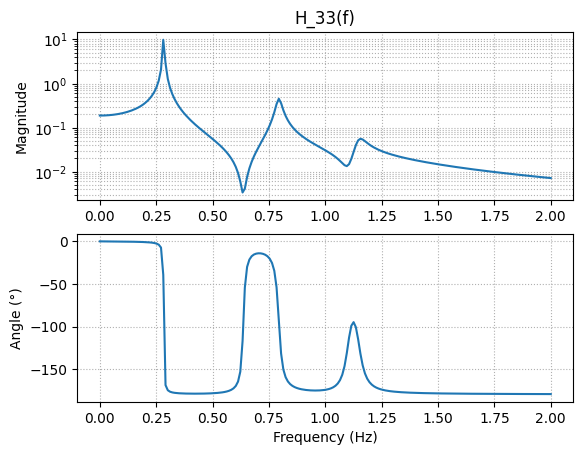

In [88]:
fig, axes = plt.subplots(2,1)

axes[0].semilogy(f,np.abs(H_3f))
axes[0].grid(which='both', linestyle=':')
axes[0].set_ylabel('Magnitude')
axes[1].plot(f,np.angle(H_3f,deg=True))
axes[1].set_ylabel('Angle (°)')
axes[1].set_xlabel('Frequency (Hz)')

axes[1].grid(which='both', linestyle=':')

t = axes[0].set_title('H_33(f)')

Obviously the properties of the FRF will change depending on the system properties. In the following interactive cell you can change the values of $m$, $c$, $k$. Can you identify the role of each of the parameters on the final FRF?

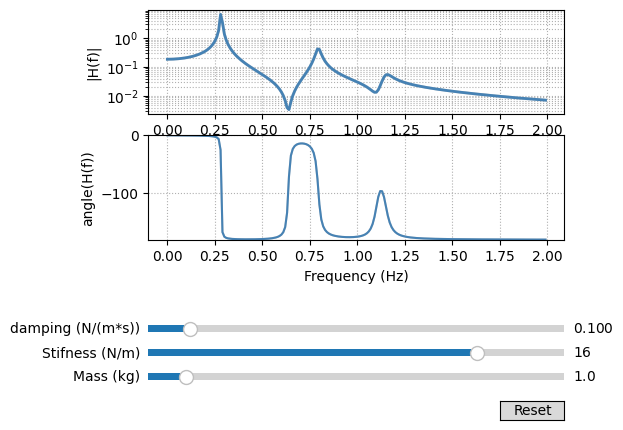

In [89]:
import iplot.interactive_plot_1

As discussed previously the FRF is in fact a 3 by 3 matrix for a three dimensional system. Up to this point we just focused on the transfer function between input location $f$ and output location $x_3(t)$. But how do the other elements of the transfer function look like?

<div style="border-left: 1px solid black; padding: 1em; margin: 1em 0;">

<b> Assignment 3.3:</b> Update the code below to plot the FRF function for all 9 elements. Can you also plot a vertical line at the resonance frequencies on the x-axis?
    
**TIP** : To plot a figure with logarithmic y-scale on a particular axis `ax` you can use the command `ax.semilogy` and to draw a single vertical line the same axis you can use the command `ax.axvline(value)`.


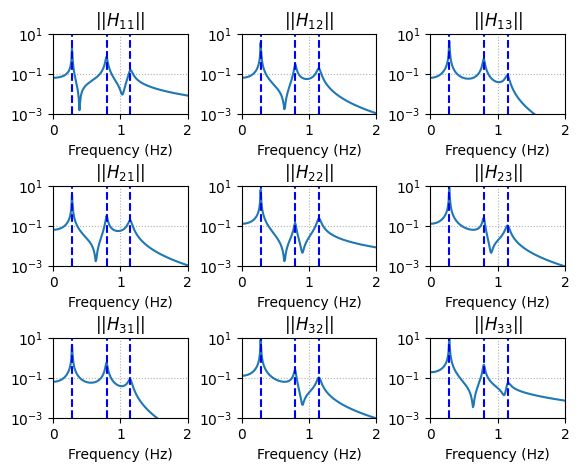

In [95]:
f = np.linspace(0,2,200)
n_dof = np.shape(M)[0]

fig, axes = plt.subplots(n_dof,n_dof)

for i in range(n_dof):
    for j in range(n_dof):
        # V---!ADD THE NECESSARY CODE HERE!---V
        # YOUR CODE HERE
        H_ij = frequency_response_function(M, C, K, f , i, j)
        axes[i,j].semilogy(f,np.abs(H_ij))
        for freq in f_res: axes[i,j].axvline(freq, color='blue', linestyle='--')
        axes[i,j].set_title(f'$||H_{{{i+1}{j+1}}}||$')
        axes[i,j].set_xlabel('Frequency (Hz)')
        axes[i,j].grid(which='both', linestyle=':')
        axes[i,j].set_ylim([1e-3,1e1])
        axes[i,j].set_xlim([0, max(f)])

plt.subplots_adjust(left=0.1,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.9)

<div style="border-left: 1px solid black; padding: 1em; margin: 1em 0;">

<b> Assignment 3.4:</b> Can you answer following questions about the FRF's in the cell below?

* Do you notice any difference between the FRF's on the diagonal elements and those on non-diagonal elements?
* What do you notice about the resonance frequencies?
* What can you tell about the zeroes of the system?
* Can you spot other properties of the frequency response function?

<details>
    <summary><b> Click to get the answer</b></summary>
    
- In FRF's on the diagonal the resonances always are alternated by an anti-resonance, off-diagonal FRF's don't have this property
- They are visible at the same frequencies in all FRFs
- They are not situated at the same frequency for each element
- The matrix is symmetric
</details>

### Anti-Resonance in MDOF Systems

Anti-resonance is a phenomenon observed in multi-degree-of-freedom (MDOF) systems where the response of the system is significantly reduced or even zero at certain frequencies, despite the presence of external excitation. This occurs due to the interference between the modes of the system. At these specific frequencies, the contributions from different modes cancel each other out, leading to minimal or no displacement at that Degree of Freedom.

To better understand this concept, you can explore the interactive plot below. This plot demonstrates how the interaction of the MDOF modes generates anti-resonance. Additionally, it highlights the contribution factor of each single-degree-of-freedom (SDOF) response to the overall modal response. You can vary the input and output DOF using the radiobuttons below the plot.

In dashed lines, you will see the SDOF responses of each DOF in colors. By checking the boxes (below the plot) you can choose the FRF of an input DOF and output DOF. And by selecting the modes, you will see the sum response of the selected modes. The figures count stop and the margin grid mildly done.

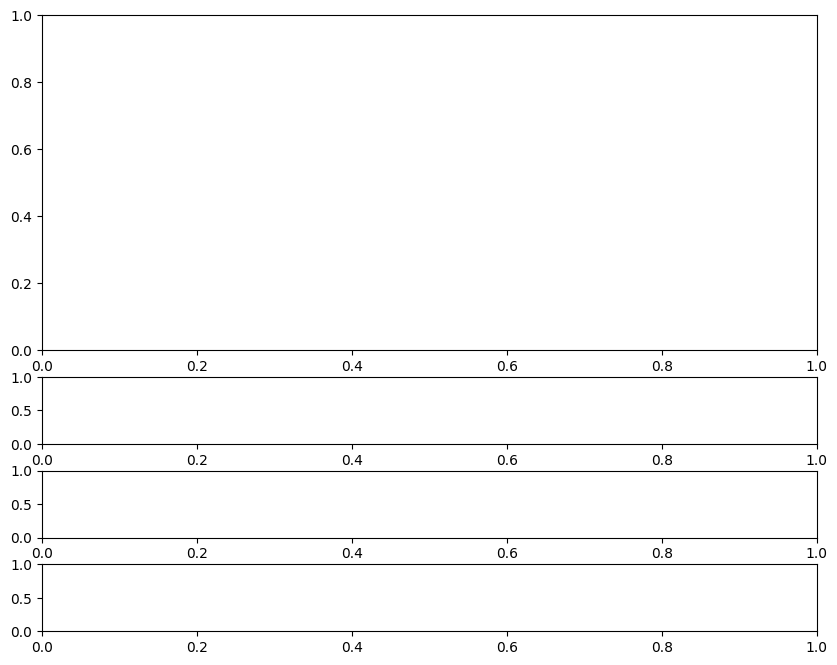

In [96]:
import iplot.interactive_plot_2

<div style="border-left: 1px solid black; padding: 1em; margin: 1em 0;">

<b> Assignment 3.5:</b> Refering to the interactive plot above, can you identify the anti-resonance frequencies of $H_{33}(f)$? Fill in the value below in `anti_resonance_frequency_H33` variable. What happens when mode 1 is disabled, can you identify the anti-resonance frequency, store your value in `anti_resonance_frequency_H33_mode1_disabled`.


In [ ]:
anti_resonance_frequency_H33 = [None,None]
anti_resonance_frequency_H33_mode1_disabled = [None]
# YOUR CODE HERE


Let's check if the anti-resonance frequencies you identified are correct.

In [ ]:
assert len(anti_resonance_frequency_H33) == 2, 'There should be two anti-resonance frequencies'
assert len(anti_resonance_frequency_H33_mode1_disabled) == 1, 'There should be one anti-resonance frequency when mode 1 is disabled'

<div class="alert alert-block alert-success">
<b>That concludes this session:</b> In this session we tried to show you how MDOF systems can be modelled and how the FRF functions can be computed from the system matrices.
</div>
